# Ablation stability of the 86 E/I-coloured triad patterns

Third notebook on the same 85-type Hippocampome connectome, after
`GSN_connectome_workflow.ipynb` (predictive) and `motif_characterization.ipynb`
(descriptive). Those two say what the subgraphs *are*. This one asks what each of them
is *for*, by removing it and measuring what breaks.

Two independent ablations over the same vocabulary of 86 Dale-consistent coloured
triad patterns:

| arm | what is removed | what is measured |
|---|---|---|
| **structural** | the type-to-type connections that carry the pattern | displacement of the linear neural-mass operator: spectral radius (stability margin), Henrici departure from normality, loop gain, and the shape of the steady state |
| **predictive** | the pattern's coloured vertex-orbit columns | out-of-fold accuracy lost when predicting the neural-mass steady state |

Neither arm is meaningful without a size control. A pattern carried by 700 connections
will move everything; a pattern carried by 8 will move nothing. Every structural
ablation is therefore scored against two null ensembles **of its own size**, one of them
matched on coupling magnitude and on how busy the connections are, and every predictive
ablation is run over folds held fixed across all 86 so the comparison is paired.

In [1]:
from __future__ import annotations

import time
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import gsn_connectome as gc
import triad_ablation as ta

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)
TABDIR = Path("motif_tables"); TABDIR.mkdir(exist_ok=True)
pd.set_option("display.width", 200, "display.max_columns", 60, "display.precision", 4)

OKABE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7",
         "#E69F00", "#56B4E9", "#F0E442", "#000000"]
COMP_COLOR = {"3E": "#D55E00", "2E 1I": "#F0A868", "1E 2I": "#8FBEDC", "3I": "#0072B2"}
DIV, SEQ = "RdBu_r", "Blues"

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold",
    "axes.labelsize": 9, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#DDDDDD", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False, "figure.facecolor": "white",
})

def save(fig, name):
    fig.savefig(FIGDIR / f"{name}.png"); return fig

def label_points(ax, x, y, labels, n=8, score=None, dx=6, fontsize=6.5):
    '''Label the n most extreme points, offset so the marker stays visible.'''
    s = np.abs(np.asarray(score if score is not None else y))
    for i in np.argsort(s)[-n:]:
        ax.annotate(labels[i], (x[i], y[i]), textcoords="offset points",
                    xytext=(dx, 3), fontsize=fontsize, color="#333333")

# how long the two null ensembles are; lower them for a quick pass
N_NULL_MAIN, N_NULL_CHECK, N_NULL_BUDGET = 200, 100, 50

## 1. Vocabulary, connections and features

Three objects are built once and reused by both arms.

* **the triad set** — every distinct cell-type triad (20,513 of them), each tagged with
  its coloured pattern. Built exactly as in `motif_characterization.ipynb`: the census
  runs on the unrolled instance graph and is then reduced to the multiset of cell types,
  so twinned types are not counted 2³ times.
* **the participation matrix** — for each of the 1,641 connections in the netlist and
  each pattern, how many triads of that pattern the connection carries. The 71 within-type
  couplings are ablatable connections too; they appear in triads as the twin dyad.
* **the coloured orbit features** — for each cell type, how many triad slots it occupies
  in each (pattern, orbit) pair. 228 columns, three or fewer per pattern.

In [2]:
ckey, cvkey, meta, vcols = ta.build_coloured_tables()
df = gc.load_netlist("mij_netlist.csv")
ctype = gc.Connectome.from_netlist(df)

index = {t: i for i, t in enumerate(ctype.names)}
EDGES = np.array([(index[a], index[b]) for a, b in zip(df.pre_neuron, df.post_neuron)])

t0 = time.time()
ts = ta.enumerate_triads(ctype, ckey)
PART = ta.edge_participation(ts, [tuple(e) for e in EDGES], len(meta))
XC = ta.coloured_vertex_features(ts, ctype.n, cvkey, len(vcols))
print(f"{len(meta)} coloured patterns, {len(vcols)} orbit columns")
print(f"{len(ts.cls):,} distinct cell-type triads ({int(ts.is_twin.sum()):,} within-type)")
print(f"{len(EDGES):,} ablatable connections "
      f"({int((EDGES[:,0]==EDGES[:,1]).sum())} within-type)")
print(f"built in {time.time()-t0:.1f}s")

counts = np.bincount(ts.pattern, minlength=len(meta))
meta = meta.assign(triads=counts,
                   connections=(PART > 0).sum(0),
                   triads_x_edges=PART.sum(0))
assert PART.sum() == sum(bin(int(c)).count("1") for c in ts.code)
assert XC.sum() == 3 * len(ts.cls)
print(f"realised patterns: {(counts > 0).sum()} of {len(meta)}  "
      f"(absent: {', '.join(meta.pattern[counts == 0])})")
display(meta.sort_values("triads", ascending=False).head(8)
            [["pattern", "triad_class", "composition", "structure", "triads", "connections"]])

86 coloured patterns, 228 orbit columns
20,513 distinct cell-type triads (1,941 within-type)
1,641 ablatable connections (71 within-type)
built in 0.4s
realised patterns: 85 of 86  (absent: 030C.1)


,pattern,triad_class,composition,structure,triads,connections
15,111U.2,111U,1E 2I,"E1<->I2, E1->I3",971,322
0,021D.1,021D,3I,"I1->I2, I1->I3",958,255
1,021D.2,021D,1E 2I,"E1->I2, E1->I3",929,147
50,120U.1,120U,3I,"I1<->I2, I1->I3, I2->I3",927,701
42,030T.1,030T,3I,"I1->I2, I1->I3, I2->I3",898,344
43,030T.2,030T,1E 2I,"E1->I2, E1->I3, I2->I3",845,539
70,120D.3,120D,1E 2I,"E2->I1, I1<->I3, E2->I3",800,595
17,111U.4,111U,2E 1I,"E1<->E2, E1->I3",779,289


## 2. The structural arm

The operator is the same linear neural-mass map used in the workflow notebook,
$S = \alpha M^{\top} / \rho(M^{\top})$ with $\alpha = 0.9$, built on the unrolled
156-instance graph. Three choices matter and are worth stating before any number appears.

**The node set is pinned.** Ablating a within-type coupling would, if the graph were
re-unrolled, delete that type's twin and change the dimension of the operator. The
instance set is therefore fixed at the intact graph's 156 nodes and only couplings are
zeroed, so the ablated and reference systems are always comparable.

**Two scales, two questions.** Under the *fixed* scale the normalisation $\alpha/\rho$ is
inherited from the intact graph, so an ablation is felt as a change in loop gain — this
is what makes $\rho_{\text{fixed}} = \alpha\,\rho_{\text{abl}}/\rho_{\text{full}}$ a
stability margin, and a value at or above 1 means the ablated system no longer settles.
Under the *re-normalised* scale $\rho$ is recomputed, which divides the overall gain back
out and leaves only the change in the *shape* of the steady state.

**The coupling lens.** The raw $m_{ij}$ span eight orders of magnitude, so
$\rho(M^{\top})$ is set by a handful of enormous couplings and is almost unmoved by
anything else. In that lens the question "which motif matters" has no answer worth
having — Section 4 demonstrates this rather than assuming it. The primary analysis
therefore runs on the sign-preserving log compression already used throughout this
project, where connections are commensurable.

In [3]:
M_LOG = gc.signed_log(ctype.M)
t0 = time.time()
S_log = ta.structural_ablation(ctype, M_LOG, EDGES, PART, meta, n_null=N_NULL_MAIN, seed=0)
print(f"structural ablation, signed-log lens: {len(S_log)} patterns in {time.time()-t0:.0f}s")

S_log = S_log.merge(meta[["pattern", "triad_class", "composition", "structure", "triads"]],
                    on="pattern")
# The empirical p cannot go below 1/(n_null+1) = 0.005, which no Benjamini-Hochberg
# threshold over 85 tests can clear. FDR is therefore taken on the z-based p, and the
# null ensembles are checked for the approximate normality that licenses it.
for m in ta.METRICS:
    S_log[f"{m}_q_matched"] = ta.fdr(ta.two_sided_p(S_log[f"{m}_z_matched"]))
shape = S_log[[f"{m}_null_{s}" for m in ta.METRICS for s in ("skew", "kurtosis")]]
print("matched-null shape across patterns (should sit near 0):")
print(shape.describe().loc[["mean", "50%", "max"]].round(2).to_string())
S_log["abs_z_rho"] = S_log["d_rho_z_matched"].abs()
S_log["abs_z_shape"] = S_log["ss_shape_z_matched"].abs()

cols = ["pattern", "composition", "n_removed", "rho_fixed", "d_rho", "d_rho_z_matched",
        "d_rho_q_matched", "ss_shape", "ss_shape_z_matched", "ss_shape_q_matched"]
display(S_log.sort_values("abs_z_rho", ascending=False).head(12)[cols])
print(f"\ndestabilised by ablation (rho_fixed >= 1): "
      f"{S_log.destabilised.sum()} patterns")
print(f"significant on stability margin (FDR < 0.05): "
      f"{(S_log.d_rho_q_matched < 0.05).sum()} of {len(S_log)}")
print(f"significant on steady-state shape  (FDR < 0.05): "
      f"{(S_log.ss_shape_q_matched < 0.05).sum()} of {len(S_log)}")

structural ablation, signed-log lens: 85 patterns in 255s
matched-null shape across patterns (should sit near 0):
      d_rho_null_skew  d_rho_null_kurtosis  d_henrici_null_skew  d_henrici_null_kurtosis  d_gain_null_skew  d_gain_null_kurtosis  ss_shape_null_skew  ss_shape_null_kurtosis
mean            -0.18                 0.11                -0.06                     0.03              0.43                  0.53                1.37                    3.82
50%             -0.16                 0.03                -0.07                    -0.02              0.47                  0.31                1.04                    1.56
max              0.25                 2.50                 0.54                     1.01              1.24                  3.77                6.86                   47.98


,pattern,composition,n_removed,rho_fixed,d_rho,d_rho_z_matched,d_rho_q_matched,ss_shape,ss_shape_z_matched,ss_shape_q_matched
82,300.2,1E 2I,487,1.0239,0.1377,9.2829,1.4025e-18,0.1993,-1.3952,0.4468
15,111U.2,1E 2I,322,0.9833,0.0926,8.5930,3.6003e-16,1.0946,4.5308,0.0002
54,120U.5,2E 1I,97,0.9941,0.1046,7.4447,2.4600e-12,0.1488,0.5604,0.7975
50,120U.1,3I,701,0.8952,-0.0053,7.4029,2.4600e-12,0.1453,-1.3316,0.4861
19,111U.6,2E 1I,225,0.9888,0.0987,7.3919,2.4600e-12,0.1359,-1.2822,0.5146
69,120D.3,1E 2I,595,0.8950,-0.0056,7.1481,1.2463e-11,0.5532,0.2154,0.9204
70,120D.4,2E 1I,355,0.9387,0.0430,7.1040,1.4712e-11,0.5045,-0.0030,0.9976
43,030T.2,1E 2I,539,0.9059,0.0066,6.8439,8.1899e-11,0.5073,0.0634,0.9896
67,120D.1,3I,624,0.8955,-0.0050,6.5639,4.9498e-10,0.1775,-0.5513,0.7975
76,210.4,2E 1I,242,0.9680,0.0755,6.5463,5.0117e-10,0.6576,3.3071,0.0097



destabilised by ablation (rho_fixed >= 1): 1 patterns
significant on stability margin (FDR < 0.05): 62 of 85
significant on steady-state shape  (FDR < 0.05): 12 of 85


### A limit on the significance testing, before the figures

The empirical p-value from a null ensemble cannot go below $1/(n+1)$, which at 200 draws
is 0.005. No Benjamini-Hochberg threshold over 85 tests can clear that, so the FDR above
is taken on the z-based p-value instead, and the shape of each null ensemble is printed
so the normal approximation that licenses it can be checked.

It holds for three of the four readouts. The **steady-state-shape null is right-skewed**
(mean skew ≈ 1.4, worst excess kurtosis ≈ 48), so its z-based p-values are optimistic and
the shape significances below are indicative, not controlled. The spectral radius, loop
gain and non-normality nulls are near-Gaussian and are fine. Raising the shape analysis to
the same footing needs a larger ensemble, not a different test.

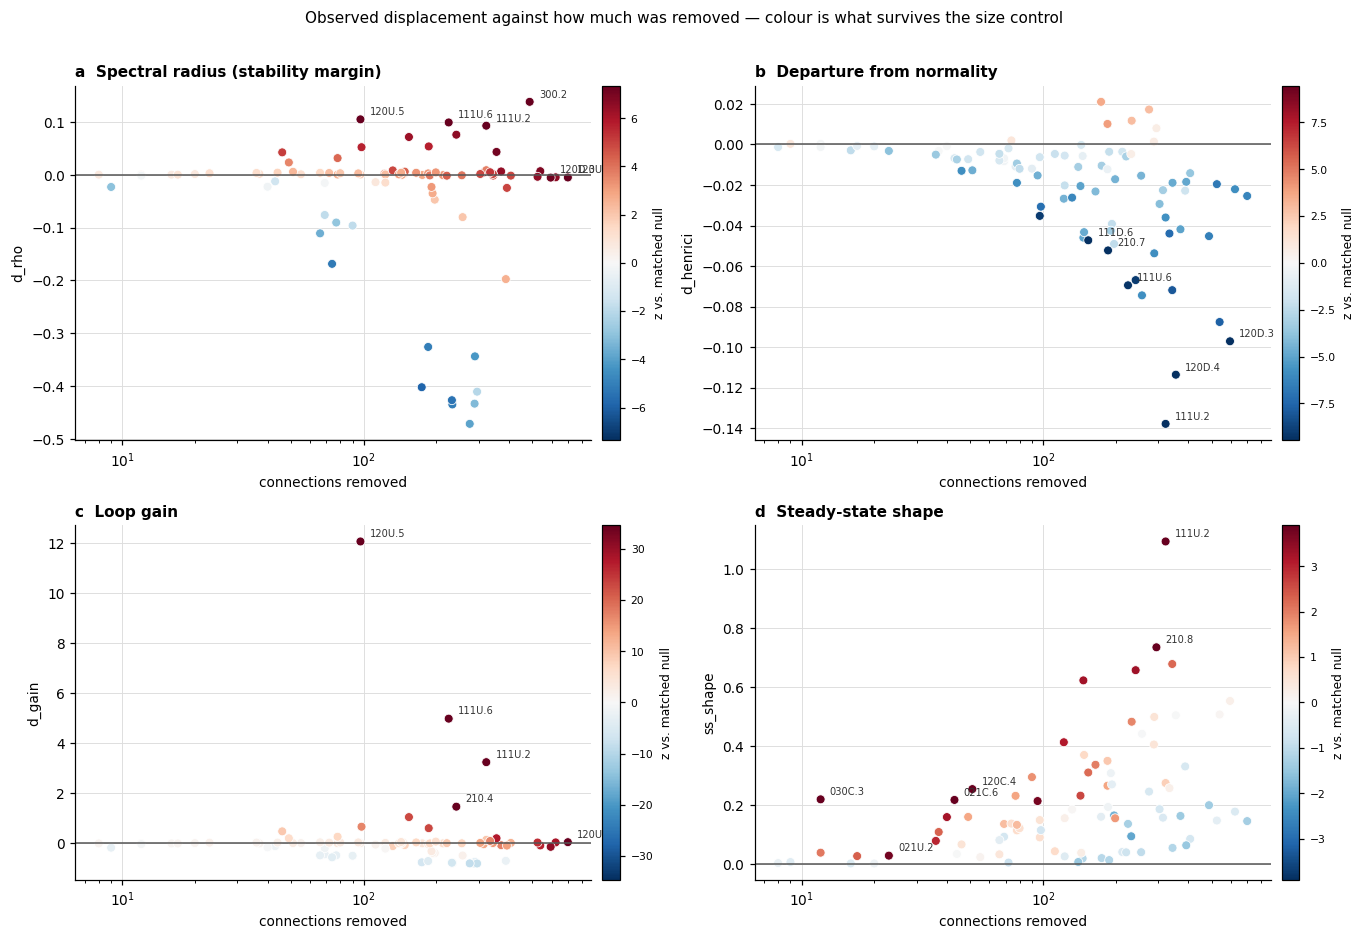

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.4))
titles = {"d_rho": "a  Spectral radius (stability margin)",
          "d_henrici": "b  Departure from normality",
          "d_gain": "c  Loop gain",
          "ss_shape": "d  Steady-state shape"}
for ax, m in zip(axes.ravel(), ta.METRICS):
    z = S_log[f"{m}_z_matched"].to_numpy()
    lim = np.nanpercentile(np.abs(z), 95)
    sc = ax.scatter(S_log.n_removed, S_log[m], c=np.clip(z, -lim, lim), cmap=DIV,
                    vmin=-lim, vmax=lim, s=34, edgecolor="white", linewidth=.5)
    ax.axhline(0, color="#555555", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("connections removed"); ax.set_ylabel(m)
    ax.set_title(titles[m], loc="left")
    label_points(ax, S_log.n_removed.to_numpy(), S_log[m].to_numpy(),
                 S_log.pattern.to_numpy(), n=6, score=z)
    cb = fig.colorbar(sc, ax=ax, fraction=.04, pad=.02)
    cb.set_label("z vs. matched null", fontsize=8); cb.ax.tick_params(labelsize=7)
fig.suptitle("Observed displacement against how much was removed — colour is what survives the size control",
             y=1.01, fontsize=10)
fig.tight_layout(); save(fig, "A1_effect_vs_size"); plt.show()

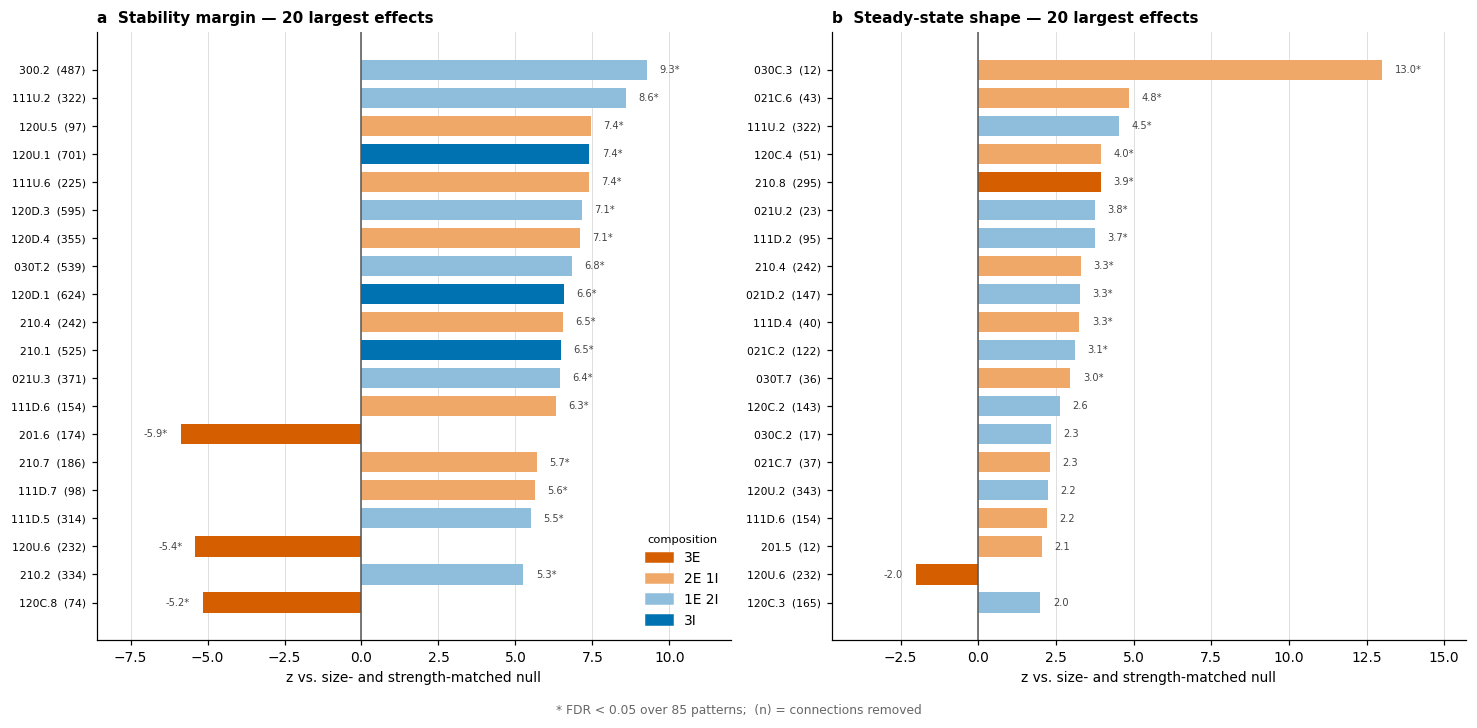

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.4))
for ax, (m, ttl) in zip(axes, [("d_rho", "a  Stability margin"),
                               ("ss_shape", "b  Steady-state shape")]):
    top = S_log.reindex(S_log[f"{m}_z_matched"].abs().sort_values().index).tail(20)
    z = top[f"{m}_z_matched"].to_numpy()
    ax.barh(np.arange(len(top)), z,
            color=[COMP_COLOR[c] for c in top.composition], height=.72)
    ax.axvline(0, color="#555555", lw=1)
    for k, (v, q) in enumerate(zip(z, top[f"{m}_q_matched"])):
        star = "*" if q < 0.05 else ""
        ax.text(v + (.4 if v > 0 else -.4), k, f"{v:.1f}{star}", va="center",
                ha="left" if v > 0 else "right", fontsize=6.5, color="#444444")
    ax.set_yticks(np.arange(len(top)),
                  [f"{p}  ({n})" for p, n in zip(top.pattern, top.n_removed)], fontsize=7)
    lo, hi = min(z.min(), 0), max(z.max(), 0)
    ax.set_xlim(lo - .18 * (hi - lo), hi + .18 * (hi - lo))
    ax.set_xlabel("z vs. size- and strength-matched null")
    ax.set_title(f"{ttl} — 20 largest effects", loc="left")
    ax.grid(axis="y", visible=False)
hs = [plt.Rectangle((0, 0), 1, 1, color=COMP_COLOR[c]) for c in COMP_COLOR]
axes[0].legend(hs, list(COMP_COLOR), loc="lower right", title="composition", title_fontsize=7.5)
fig.text(.5, -.02, "* FDR < 0.05 over 85 patterns;  (n) = connections removed",
         ha="center", fontsize=8, color="#666666")
fig.tight_layout(); save(fig, "A2_ranked_structural"); plt.show()

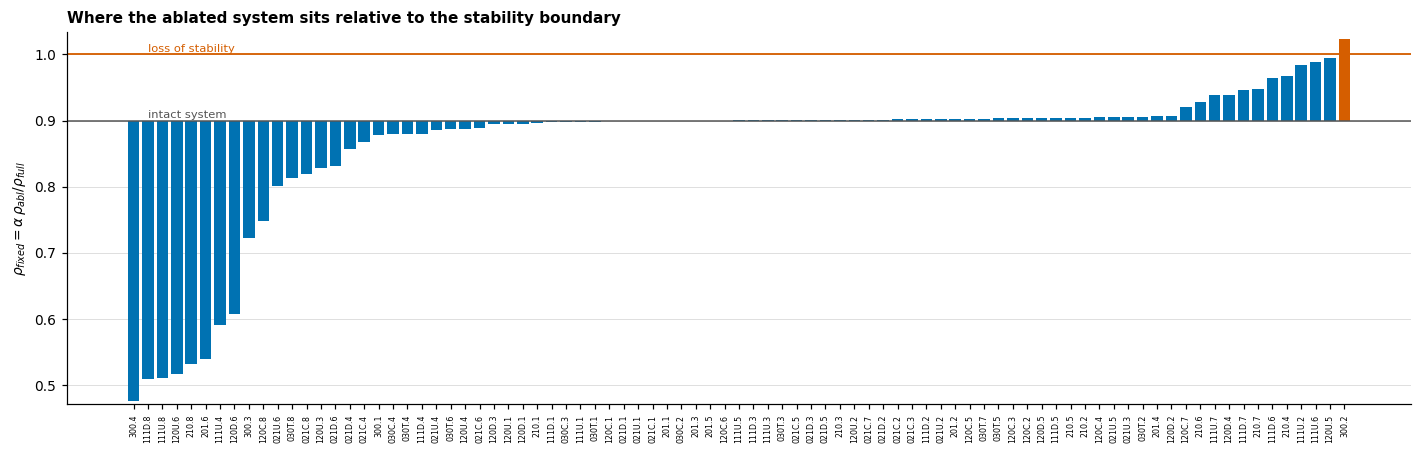

,pattern,structure,n_removed,rho_fixed,d_gain
82,300.2,"E1<->I2, E1<->I3, I2<->I3",487,1.0239,NaN


In [6]:
srt = S_log.sort_values("rho_fixed")
fig, ax = plt.subplots(figsize=(13, 4.2))
col = [OKABE[1] if d else OKABE[0] for d in srt.destabilised]
ax.bar(np.arange(len(srt)), srt.rho_fixed - 0.9, bottom=0.9, color=col, width=.8)
ax.axhline(0.9, color="#555555", lw=1)
ax.axhline(1.0, color=OKABE[1], lw=1.2)
ax.text(1, 0.905, "intact system", fontsize=7.5, color="#555555")
ax.text(1, 1.004, "loss of stability", fontsize=7.5, color=OKABE[1])
ax.set_xticks(np.arange(len(srt)), srt.pattern, rotation=90, fontsize=5.2)
ax.set_ylabel(r"$\rho_{fixed}=\alpha\,\rho_{abl}/\rho_{full}$")
ax.set_ylim(min(0.86, srt.rho_fixed.min() * .99), max(1.02, srt.rho_fixed.max() * 1.01))
ax.set_title("Where the ablated system sits relative to the stability boundary", loc="left")
ax.grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "A3_stability_margin"); plt.show()

d = srt[srt.destabilised]
if len(d):
    display(d[["pattern", "structure", "n_removed", "rho_fixed", "d_gain"]])

## 3. Does the ranking hold? Two stability checks

A ranking is only worth reporting if it survives the arbitrary choices that produced it.
Two are checked here: the coupling lens, and the decision to remove *every* connection
carrying a pattern rather than a fixed number of them.

In [7]:
t0 = time.time()
S_raw = ta.structural_ablation(ctype, ctype.M, EDGES, PART, meta,
                               n_null=N_NULL_CHECK, seed=1)
S_bud = ta.structural_ablation(ctype, M_LOG, EDGES, PART, meta, budget=40,
                               n_null=N_NULL_BUDGET, seed=2)
print(f"two checks in {time.time()-t0:.0f}s")

def rank_agreement(a, b, col):
    j = a[["pattern", col]].merge(b[["pattern", col]], on="pattern", suffixes=("_a", "_b"))
    r = np.argsort(np.argsort(j[f"{col}_a"])), np.argsort(np.argsort(j[f"{col}_b"]))
    return float(np.corrcoef(r[0], r[1])[0, 1]), j

rows = []
for m in ta.METRICS:
    c = f"{m}_z_matched"
    rows.append(dict(metric=m,
                     lens_raw_vs_log=rank_agreement(S_log, S_raw, c)[0],
                     budget40_vs_full=rank_agreement(S_log, S_bud, c)[0]))
agree = pd.DataFrame(rows).set_index("metric")
display(agree.round(3))

two checks in 148s


,lens_raw_vs_log,budget40_vs_full
metric,,
d_rho,0.764,0.635
d_henrici,0.516,0.444
d_gain,0.883,0.611
ss_shape,0.560,0.549


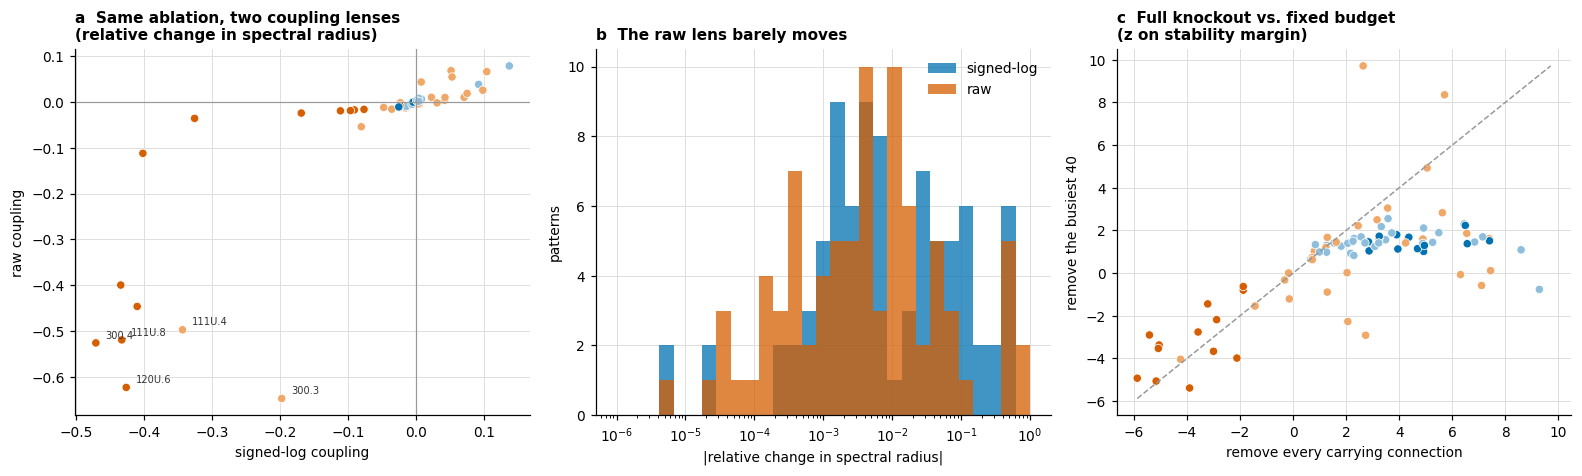

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4))
ax = axes[0]
j = S_log[["pattern", "d_rho", "composition"]].merge(
        S_raw[["pattern", "d_rho"]], on="pattern", suffixes=("_log", "_raw"))
ax.scatter(j.d_rho_log, j.d_rho_raw, s=30, c=[COMP_COLOR[c] for c in j.composition],
           edgecolor="white", linewidth=.5)
ax.axhline(0, color="#999999", lw=.8); ax.axvline(0, color="#999999", lw=.8)
ax.set_xlabel("signed-log coupling"); ax.set_ylabel("raw coupling")
ax.set_title("a  Same ablation, two coupling lenses\n(relative change in spectral radius)", loc="left")
label_points(ax, j.d_rho_log.to_numpy(), j.d_rho_raw.to_numpy(), j.pattern.to_numpy(), n=5)

ax = axes[1]
ax.hist(S_log.d_rho.abs(), bins=np.logspace(-6, 0, 30), alpha=.75, color=OKABE[0],
        label="signed-log")
ax.hist(S_raw.d_rho.abs(), bins=np.logspace(-6, 0, 30), alpha=.75, color=OKABE[1],
        label="raw")
ax.set_xscale("log"); ax.set_xlabel("|relative change in spectral radius|")
ax.set_ylabel("patterns"); ax.legend()
ax.set_title("b  The raw lens barely moves", loc="left")

ax = axes[2]
j2 = S_log[["pattern", "d_rho_z_matched", "composition"]].merge(
        S_bud[["pattern", "d_rho_z_matched"]], on="pattern", suffixes=("_full", "_b40"))
ax.scatter(j2.d_rho_z_matched_full, j2.d_rho_z_matched_b40, s=30,
           c=[COMP_COLOR[c] for c in j2.composition], edgecolor="white", linewidth=.5)
lo = min(j2.d_rho_z_matched_full.min(), j2.d_rho_z_matched_b40.min())
hi = max(j2.d_rho_z_matched_full.max(), j2.d_rho_z_matched_b40.max())
ax.plot([lo, hi], [lo, hi], color="#999999", lw=1, ls="--")
ax.set_xlabel("remove every carrying connection"); ax.set_ylabel("remove the busiest 40")
ax.set_title("c  Full knockout vs. fixed budget\n(z on stability margin)", loc="left")
fig.tight_layout(); save(fig, "A4_stability_checks"); plt.show()

## 4. The predictive arm

Same vocabulary, different question: how much does each pattern's *count* contribute to
predicting the neural-mass steady state of a cell type it was never trained on?

The model here is ridge regression on the 8 first-order features plus the 228 coloured
orbit counts, not the GSN. Retraining a GSN 86 times over many seeds is out of budget,
and for an importance ranking a regularised linear readout is the better instrument
anyway: it is deterministic, so a difference between two ablations is not swamped by
initialisation noise. Its accuracy is in the same range as the GSN reported in the
workflow notebook, which is the reason to trust it as a stand-in.

Folds are drawn over cell types once and reused by every ablation, so each comparison is
paired. Both directions are reported — what is lost when a pattern is *removed* from the
full model, and what it is worth *alone* on top of the first-order features — because the
orbit counts are strongly collinear and leave-one-out alone systematically understates a
pattern whose information is duplicated elsewhere.

In [9]:
from sklearn.linear_model import RidgeCV

X, y, feat_names, twin_spread = ta.type_level_design(ctype, XC, target="steady_state")
print(f"design matrix {X.shape}, target = signed-log steady state")
print(f"twin agreement on the target: max within-pair spread {twin_spread:.2e} "
      "(exchangeable by construction, so this must be ~0)")

N_BASE = 8
RIDGE_ALPHA = float(RidgeCV(alphas=np.logspace(-2, 4, 25)).fit(X, y).alpha_)
FOLDS = ta.make_folds(len(y), n_repeat=20, k=5, seed=7)
print(f"ridge alpha {RIDGE_ALPHA:.1f}, 20 repeats x 5 folds over cell types")

t0 = time.time()
P = ta.predictive_ablation(X, y, N_BASE, vcols, meta, FOLDS, RIDGE_ALPHA)
print(f"predictive ablation in {time.time()-t0:.0f}s")
P = P.merge(meta[["pattern", "triad_class", "composition", "triads", "structure"]], on="pattern")
P["q_solo"] = ta.fdr(ta.two_sided_p(P.t_solo))
P["q_lopo"] = ta.fdr(ta.two_sided_p(P.t_lopo))

print(f"\nR2 first-order features only : {P.r2_base_only.iloc[0]:.3f}")
print(f"R2 with all 228 orbit columns: {P.r2_full.iloc[0]:.3f}")
display(P.sort_values("d_solo", ascending=False).head(12)
         [["pattern", "composition", "triads", "d_solo", "d_solo_pos_frac", "q_solo",
           "d_lopo", "d_lopo_pos_frac", "q_lopo"]])

design matrix (85, 236), target = signed-log steady state
twin agreement on the target: max within-pair spread 2.78e-16 (exchangeable by construction, so this must be ~0)
ridge alpha 17.8, 20 repeats x 5 folds over cell types


predictive ablation in 14s

R2 first-order features only : 0.464
R2 with all 228 orbit columns: 0.574


,pattern,composition,triads,d_solo,d_solo_pos_frac,q_solo,d_lopo,d_lopo_pos_frac,q_lopo
30,111D.3,1E 2I,41,0.1946,1.00,0.0000e+00,0.0708,1.00,3.6344e-123
16,111U.3,1E 2I,114,0.0850,1.00,4.3856e-161,0.0050,0.85,2.1263e-07
3,021D.4,2E 1I,536,0.0845,1.00,0.0000e+00,0.0129,1.00,3.2734e-82
7,021C.2,1E 2I,197,0.0749,1.00,1.5393e-85,0.0049,0.95,1.0119e-10
19,111U.6,2E 1I,326,0.0744,1.00,0.0000e+00,0.0030,0.95,1.0477e-10
37,201.2,1E 2I,43,0.0463,1.00,6.6100e-151,0.0064,0.90,9.0501e-16
34,111D.7,2E 1I,44,0.0412,0.95,1.9195e-33,-0.0007,0.40,6.8072e-01
26,021U.5,2E 1I,166,0.0399,1.00,3.1274e-93,-0.0021,0.10,1.3030e-07
24,021U.3,1E 2I,651,0.0389,1.00,3.1515e-72,-0.0017,0.05,8.5884e-15
17,111U.4,2E 1I,779,0.0377,1.00,1.6182e-122,-0.0010,0.20,4.0237e-04


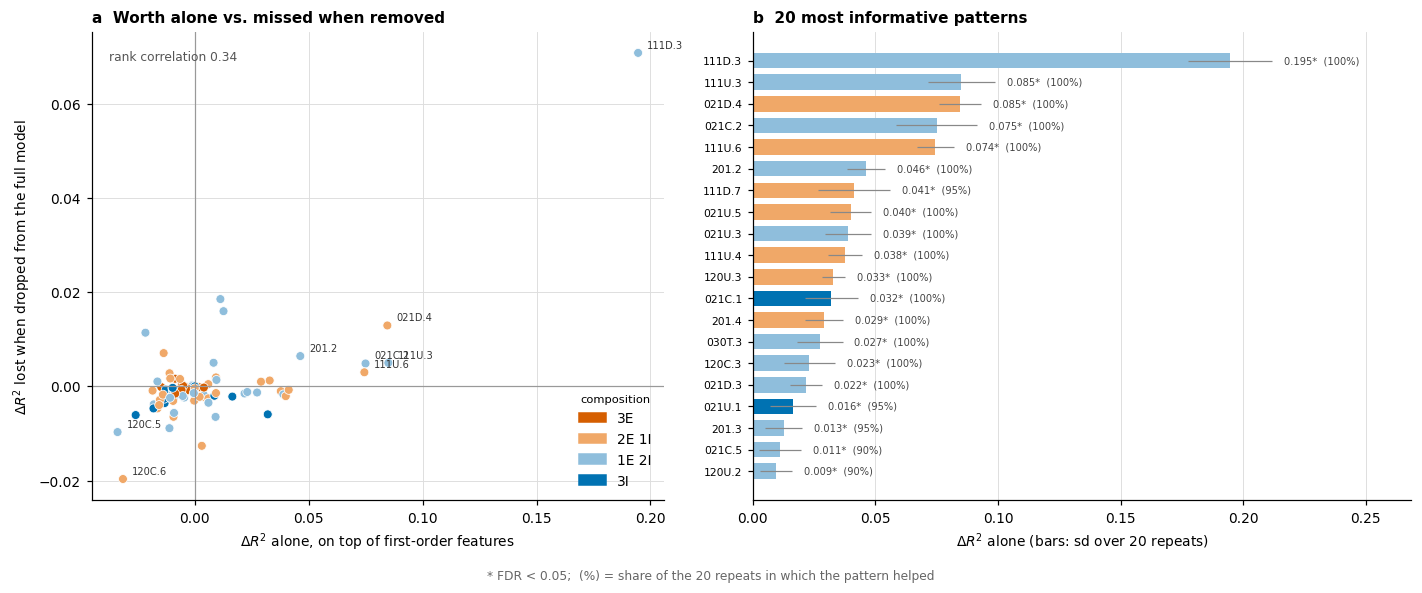

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), width_ratios=[1, 1.15])
ax = axes[0]
ax.scatter(P.d_solo, P.d_lopo, s=34, c=[COMP_COLOR[c] for c in P.composition],
           edgecolor="white", linewidth=.5)
ax.axhline(0, color="#999999", lw=.8); ax.axvline(0, color="#999999", lw=.8)
ax.set_xlabel(r"$\Delta R^2$ alone, on top of first-order features")
ax.set_ylabel(r"$\Delta R^2$ lost when dropped from the full model")
ax.set_title("a  Worth alone vs. missed when removed", loc="left")
label_points(ax, P.d_solo.to_numpy(), P.d_lopo.to_numpy(), P.pattern.to_numpy(),
             n=8, score=P.d_solo.to_numpy() + P.d_lopo.to_numpy())
r = np.corrcoef(np.argsort(np.argsort(P.d_solo)), np.argsort(np.argsort(P.d_lopo)))[0, 1]
ax.text(.03, .96, f"rank correlation {r:.2f}", transform=ax.transAxes, fontsize=8,
        color="#555555", va="top")
hs = [plt.Rectangle((0, 0), 1, 1, color=COMP_COLOR[c]) for c in COMP_COLOR]
ax.legend(hs, list(COMP_COLOR), loc="lower right", title="composition", title_fontsize=7.5)

ax = axes[1]
top = P.sort_values("d_solo").tail(20)
ax.barh(np.arange(len(top)), top.d_solo, color=[COMP_COLOR[c] for c in top.composition],
        height=.72, xerr=top.d_solo_sd, error_kw=dict(ecolor="#888888", lw=.8))
for k, (v, sd, q, f) in enumerate(zip(top.d_solo, top.d_solo_sd, top.q_solo,
                                      top.d_solo_pos_frac)):
    ax.text(v + sd + top.d_solo.max() * .025, k,
            f"{v:.3f}{'*' if q < .05 else ''}  ({f:.0%})",
            va="center", fontsize=6.5, color="#444444")
ax.set_yticks(np.arange(len(top)), top.pattern, fontsize=7)
ax.set_xlim(0, top.d_solo.max() * 1.38)
ax.set_xlabel(r"$\Delta R^2$ alone (bars: sd over 20 repeats)")
ax.set_title("b  20 most informative patterns", loc="left")
ax.grid(axis="y", visible=False)
fig.text(.5, -.02, "* FDR < 0.05;  (%) = share of the 20 repeats in which the pattern helped",
         ha="center", fontsize=8, color="#666666")
fig.tight_layout(); save(fig, "A5_predictive_ablation"); plt.show()

## 5. One ranking

The two arms measure different things and there is no reason for them to agree: a
pattern can be structurally load-bearing without its *count* being a useful regressor,
and a rare pattern can be highly diagnostic without carrying the dynamics. The combined
rank below is the mean of the two rank positions, and is a convenience for reading the
table — the two component ranks are the evidence.

In [11]:
rank = (S_log[["pattern", "triad_class", "composition", "structure", "triads", "n_removed",
               "rho_fixed", "destabilised", "d_rho", "d_rho_z_matched", "d_rho_q_matched",
               "ss_shape", "ss_shape_z_matched", "ss_shape_q_matched"]]
        .merge(P[["pattern", "d_solo", "d_solo_sd", "d_solo_pos_frac", "q_solo",
                  "d_lopo", "q_lopo"]], on="pattern"))
rank["rank_structural"] = rank[["d_rho_z_matched", "ss_shape_z_matched"]].abs().max(axis=1) \
                              .rank(ascending=False)
rank["rank_predictive"] = rank.d_solo.rank(ascending=False)
rank["rank_combined"] = (rank.rank_structural + rank.rank_predictive) / 2
rank = rank.sort_values("rank_combined").reset_index(drop=True)

rho_s = np.corrcoef(np.argsort(np.argsort(rank.rank_structural)),
                    np.argsort(np.argsort(rank.rank_predictive)))[0, 1]
print(f"rank correlation between the two arms: {rho_s:.2f}")
display(rank.head(20)[["pattern", "composition", "structure", "triads",
                       "rank_structural", "rank_predictive", "rank_combined",
                       "d_rho_z_matched", "ss_shape_z_matched", "d_solo"]])

rank correlation between the two arms: -0.20


,pattern,composition,structure,triads,rank_structural,rank_predictive,rank_combined,d_rho_z_matched,ss_shape_z_matched,d_solo
0,111U.6,2E 1I,"E1<->I2, E1->E3",326,6.0,5.0,5.5,7.3919,-1.2822,0.0744
1,021U.3,1E 2I,"E2->I1, I3->I1",651,13.0,9.0,11.0,6.4461,-1.4153,0.0389
2,111D.7,2E 1I,"I1<->E2, E3->I1",44,17.0,7.0,12.0,5.6254,-0.7169,0.0412
3,030C.3,2E 1I,"E1->E2, I3->E1, E2->I3",5,1.0,33.0,17.0,-0.1728,13.0068,0.0021
4,111D.6,2E 1I,"E1<->I2, E3->E1",135,14.0,27.0,20.5,6.3101,2.2104,0.0059
5,201.4,2E 1I,"E1<->E2, E1<->I3",67,28.0,13.0,20.5,4.8913,0.0546,0.0290
6,021U.5,2E 1I,"E2->I1, E3->I1",166,33.0,8.0,20.5,4.3263,0.7637,0.0399
7,111U.2,1E 2I,"E1<->I2, E1->I3",971,3.0,41.0,22.0,8.5930,4.5308,-0.0012
8,111U.4,2E 1I,"E1<->E2, E1->I3",779,34.0,10.0,22.0,-4.2455,0.5406,0.0377
9,021C.2,1E 2I,"I2->E1, E1->I3",197,45.0,4.0,24.5,3.5782,3.1183,0.0749


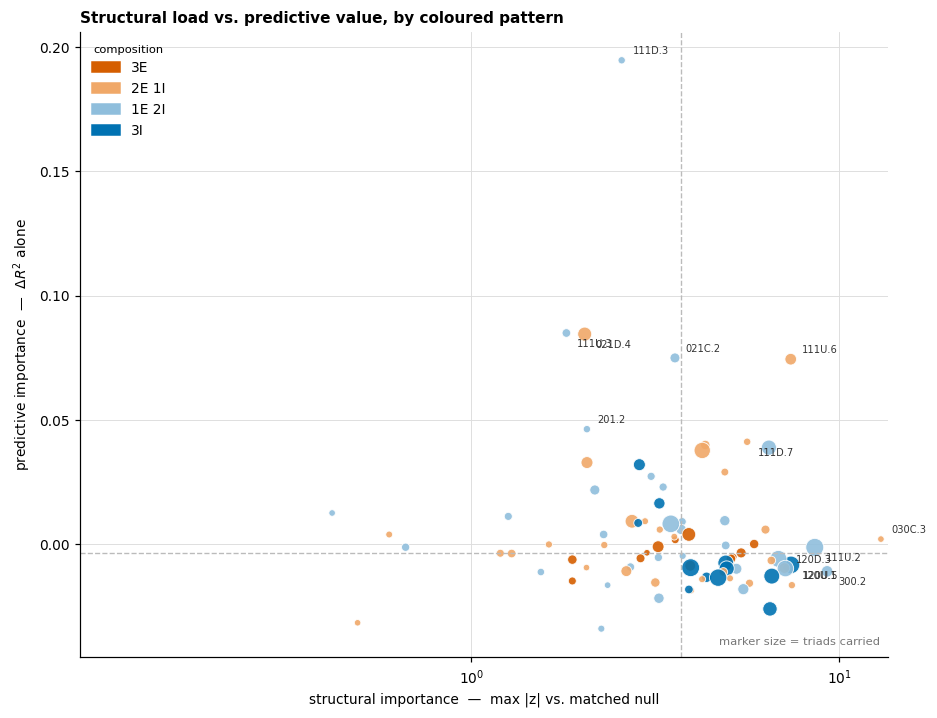

In [12]:
fig, ax = plt.subplots(figsize=(8.6, 6.6))
xs = rank[["d_rho_z_matched", "ss_shape_z_matched"]].abs().max(axis=1)
ys = rank.d_solo
sizes = 18 + 120 * (rank.triads / rank.triads.max())
ax.scatter(xs, ys, s=sizes, c=[COMP_COLOR[c] for c in rank.composition],
           edgecolor="white", linewidth=.6, alpha=.9)
ax.axhline(ys.median(), color="#BBBBBB", lw=.9, ls="--")
ax.axvline(xs.median(), color="#BBBBBB", lw=.9, ls="--")
ax.set_xscale("symlog", linthresh=1)
ax.set_xlabel("structural importance  —  max |z| vs. matched null")
ax.set_ylabel(r"predictive importance  —  $\Delta R^2$ alone")
ax.set_title("Structural load vs. predictive value, by coloured pattern", loc="left")
lab_x, lab_y = xs.to_numpy(), ys.to_numpy()
names = rank.pattern.to_numpy()
pick = sorted(set(np.argsort(lab_x)[-7:]) | set(np.argsort(lab_y)[-7:]))
for n_, i in enumerate(pick):
    ax.annotate(names[i], (lab_x[i], lab_y[i]), textcoords="offset points",
                xytext=(7, 4 if n_ % 2 == 0 else -9), fontsize=6.5, color="#333333")
ax.text(.99, .02, "marker size = triads carried", transform=ax.transAxes, ha="right",
        fontsize=7.5, color="#777777")
hs = [plt.Rectangle((0, 0), 1, 1, color=COMP_COLOR[c]) for c in COMP_COLOR]
ax.legend(hs, list(COMP_COLOR), loc="upper left", title="composition", title_fontsize=7.5)
fig.tight_layout(); save(fig, "A6_combined_ranking"); plt.show()

## 6. The colouring, not the topology, sets the sign

The clearest result in the structural arm is not about any one pattern. Within a single
triad class the excitatory/inhibitory colouring moves the ablated system further than
most differences *between* classes, and it does so in a consistent direction. An
uncoloured 13-class vocabulary averages these apart and sees none of it.

,min_rho,max_rho,n_variants,spread
triad_class,,,,
300,0.476,1.024,4,0.548
111U,0.510,0.989,8,0.478
120U,0.516,0.994,6,0.478
111D,0.509,0.964,8,0.455
210,0.531,0.968,8,0.437
201,0.538,0.907,6,0.369
120D,0.607,0.939,6,0.332
120C,0.748,0.921,8,0.173
021U,0.800,0.905,6,0.105



median rho_fixed by composition (intact system = 0.900):
composition
1E 2I    0.902
2E 1I    0.902
3E       0.607
3I       0.898


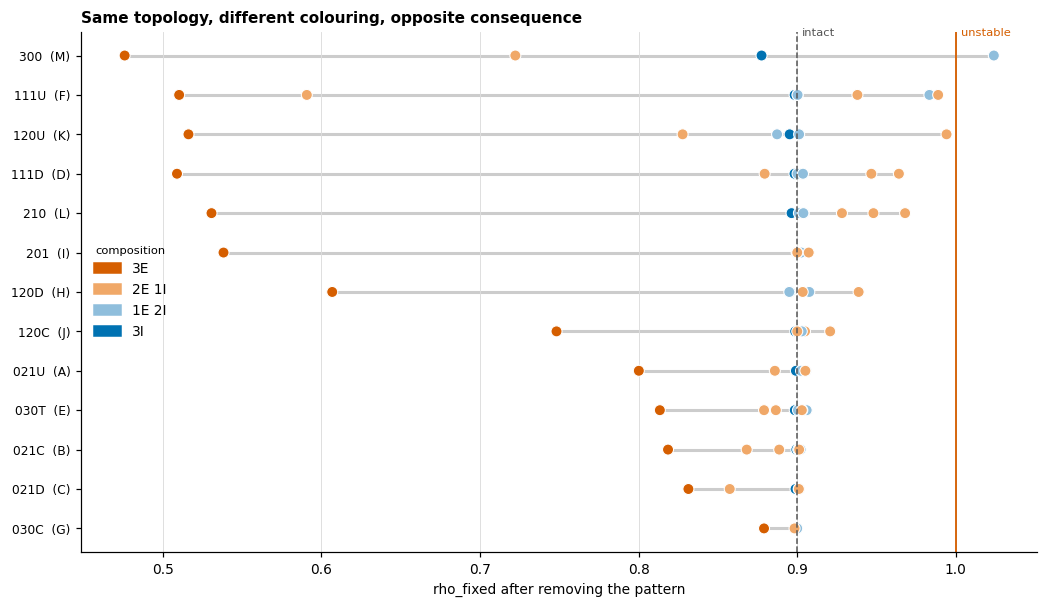

In [13]:
spread = (S_log.groupby("triad_class")
          .agg(min_rho=("rho_fixed", "min"), max_rho=("rho_fixed", "max"),
               n_variants=("pattern", "size")))
spread["spread"] = spread.max_rho - spread.min_rho
spread = spread.sort_values("spread")
display(spread.sort_values("spread", ascending=False).round(3))
print("\nmedian rho_fixed by composition (intact system = 0.900):")
print(S_log.groupby("composition").rho_fixed.median().round(3).to_string())

fig, ax = plt.subplots(figsize=(9.6, 5.6))
for r, cls in enumerate(spread.index):
    sub = S_log[S_log.triad_class == cls]
    ax.plot([sub.rho_fixed.min(), sub.rho_fixed.max()], [r, r], color="#CCCCCC", lw=2,
            zorder=0, solid_capstyle="round")
    ax.scatter(sub.rho_fixed, np.full(len(sub), r), s=52, zorder=2,
               c=[COMP_COLOR[c] for c in sub.composition], edgecolor="white", linewidth=.7)
ax.axvline(0.9, color="#555555", lw=1, ls="--")
ax.axvline(1.0, color=OKABE[1], lw=1.2)
ax.text(0.903, len(spread) - .5, "intact", fontsize=7.5, color="#555555")
ax.text(1.003, len(spread) - .5, "unstable", fontsize=7.5, color=OKABE[1])
ax.set_yticks(range(len(spread)),
              [f"{c}  ({gc.REES_SUPERPATTERN[c]})" for c in spread.index], fontsize=8)
ax.set_xlabel("rho_fixed after removing the pattern")
ax.set_title("Same topology, different colouring, opposite consequence", loc="left")
ax.grid(axis="y", visible=False)
hs = [plt.Rectangle((0, 0), 1, 1, color=COMP_COLOR[c]) for c in COMP_COLOR]
ax.legend(hs, list(COMP_COLOR), loc="center left", title="composition", title_fontsize=7.5)
fig.tight_layout(); save(fig, "A7_colouring_sets_the_sign"); plt.show()

In [14]:
tables = {
    "ablation_structural_signedlog": S_log,
    "ablation_structural_raw": S_raw,
    "ablation_structural_budget40": S_bud,
    "ablation_predictive": P,
    "ablation_rank_agreement": agree,
    "ablation_ranked": rank,
    "ablation_class_colour_spread": spread,
}
for name, t in tables.items():
    t.to_csv(TABDIR / f"{name}.csv",
             index=name in ("ablation_rank_agreement", "ablation_class_colour_spread"))
    print(f"{name:36s} {t.shape[0]:>4} x {t.shape[1]}")

ablation_structural_signedlog          85 x 54
ablation_structural_raw                85 x 44
ablation_structural_budget40           85 x 44
ablation_predictive                    86 x 20
ablation_rank_agreement                 4 x 2
ablation_ranked                        85 x 23
ablation_class_colour_spread           13 x 4


## 7. What the ablations say

**The colouring sets the sign.** Within the fully reciprocal triangle, removing the
all-excitatory colouring drops the loop gain from 0.900 to 0.476, while removing the
one-excitatory/two-inhibitory colouring pushes it to 1.024 — past the boundary, the only
ablation in the vocabulary that destabilises the system. Same topology, opposite
consequence, and the spread inside that one class (0.548) exceeds the difference between
most pairs of classes. Colour dependence is large in every class built on reciprocal dyads
(300, 111U, 120U, 111D, 210: 0.44–0.55) and almost absent in the sparse classes
(021D, 021C, 030T, 030C: 0.02–0.11) — which is where it should be, since a reciprocal loop
is where the E/I sign decides positive from negative feedback.

**The ablation recovers E/I balance without being told about it.** The five most
stabilising ablations in the vocabulary are all purely excitatory patterns; the
destabilising end is mixed E/I. 45 of 85 ablations *raise* the spectral radius. Median
$\rho_{fixed}$ after ablation is 0.607 for 3E patterns against ≈ 0.90 for every other
composition.

**Non-normality is carried by mixed-sign asymmetric triads.** 76 of 85 ablations reduce
the Henrici departure from normality, led by `111U.2` (−0.138), `120D.4` (−0.113) and
`120D.3` (−0.097) — a reciprocal E–I dyad plus an asymmetric third edge in each case.
Purely excitatory patterns move it the other way.

**Shape is robust where gain is not.** Only 12 of 85 patterns shift the steady-state
ordering beyond their matched null, and several shift it *less* than a matched random
removal would (`120U.6`: 0.094 observed against 0.327 expected) — those connections are
functionally redundant.

**The two arms disagree**, rank-correlating at −0.20. Structural load sits on abundant
patterns spread over hundreds of connections; predictive value sits on rare ones whose
presence is diagnostic of where a cell type sits. `111D.3` (`I1<->E2, I3->I1`, 41 triads)
reaches R² = 0.66 from three columns — above the full 228-column model — and still adds
0.071 when everything else is present, in every repeat. Part of that is the estimator:
85 cell types and 228 collinear columns under one ridge penalty favour a compact feature
set. The combined rank in Section 5 is a reading convenience, not a result.

**Mixed compositions dominate both arms.** The top 20 by combined rank are 9 × 1E2I,
8 × 2E1I, 2 × 3E and 1 × 3I, against a vocabulary that is 30/30/13/12.

### What would sharpen this

1. Retrain GSN-e with the top- and bottom-ranked patterns held out — about 15 retrains,
   not 86 — to confirm the ridge surrogate's ordering on the real model.
2. Enlarge the null ensemble for the steady-state-shape readout so its significances can
   be FDR-controlled.
3. Remove a minimal hitting set per pattern instead of every carrying connection. The
   matched null controls for size and strength, not for the fact that a connection removed
   for one pattern is also removed from every other pattern it carries.